<a href="https://colab.research.google.com/github/andrewtran117/agentic-chemist/blob/main/Penguin_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
Andrew and Aaron's Penguin Project
```



In [ ]:
# ============================================================
# CELL 1 — Imports
# ============================================================

# pandas: the main tool for working with tables of data (rows + columns).
# Nearly all Python data analysis starts here.
import pandas as pd

# numpy: fast math on arrays of numbers. pandas is built on top of it.
import numpy as np

# matplotlib: the base plotting library.
import matplotlib.pyplot as plt

# seaborn: a friendlier layer on top of matplotlib. Nicer default styling,
# and it ships with a few practice datasets so we don't need to upload files.
import seaborn as sns

# Makes plots look a bit cleaner. Purely cosmetic.
sns.set_theme(style="whitegrid")

print("Setup complete. pandas version:", pd.__version__)


Setup complete. pandas version: 2.2.3


In [ ]:
# ============================================================
# CELL 2 — Load a dataset
# ============================================================

# "penguins" is a small real dataset: body measurements of 344 penguins
# from three species in Antarctica. Great for learning because it has a mix
# of numeric columns (bill length, body mass) and text/category columns
# (species, island, sex) — plus some missing values to practice on.
df = sns.load_dataset("penguins")

# "df" is short for DataFrame — the pandas name for a table.
# .head() shows the first 5 rows so you can eyeball what you're working with.
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
# ============================================================
# CELL 3 — First look at the data
# ============================================================

# ALWAYS do this before analyzing anything. You're answering:
# How big is this? What are the columns? What's missing?

# .shape gives (number_of_rows, number_of_columns)
print("Shape (rows, columns):", df.shape)

# .columns lists the column names
print("\nColumns:", list(df.columns))

# .info() shows each column's data type and how many non-null values it has.
# "object" = text, "float64" = decimal number, "int64" = whole number.
print("\n--- info() ---")
df.info()

# .describe() gives summary stats (count, mean, std dev, min, quartiles, max)
# for every numeric column at once.
print("\n--- describe() ---")
print(df.describe())

# .isna() marks every missing cell as True; .sum() counts them per column.
print("\n--- missing values per column ---")
print(df.isna().sum())

Shape (rows, columns): (344, 7)

Columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

--- describe() ---
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584     

In [ ]:
# ============================================================
# CELL 4 — Cleaning: handling missing values
# ============================================================

# Real data is always messy. Two common fixes:
#   1. Drop the rows with missing values (simple, but you lose data)
#   2. Fill them in with something sensible (mean, median, "unknown")

# Option 1: drop rows that have ANY missing value.
# We assign the result to a NEW variable so the original `df` stays intact.
df_clean = df.dropna()
print("Rows before:", len(df), "| Rows after dropping missing:", len(df_clean))

# Option 2 (for reference): fill missing body mass with the column's median.
# .copy() avoids editing the original table by accident.
df_filled = df.copy()
df_filled["body_mass_g"] = df_filled["body_mass_g"].fillna(
    df_filled["body_mass_g"].median()
)

# For the rest of this tutorial we'll use the dropped version.
df = df_clean

Rows before: 344 | Rows after dropping missing: 333


Average bill length: 43.99279279279279

Subset preview:
  species  body_mass_g     sex
0  Adelie       3750.0    Male
1  Adelie       3800.0  Female
2  Adelie       3250.0  Female

Penguins over 5000g: 61
Males over 5000g: 56
--- Penguins per species ---
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

--- Average measurements by species ---
           bill_length_mm  body_mass_g
species                               
Adelie          38.823973  3706.164384
Chinstrap       48.833824  3733.088235
Gentoo          47.568067  5092.436975

--- Average body mass by species AND sex ---
species    sex   
Adelie     Female    3368.835616
           Male      4043.493151
Chinstrap  Female    3527.205882
           Male      3938.970588
Gentoo     Female    4679.741379
           Male      5484.836066
Name: body_mass_g, dtype: float64

--- Multiple stats at once ---
           count         mean     min     max
species                                      
Adel

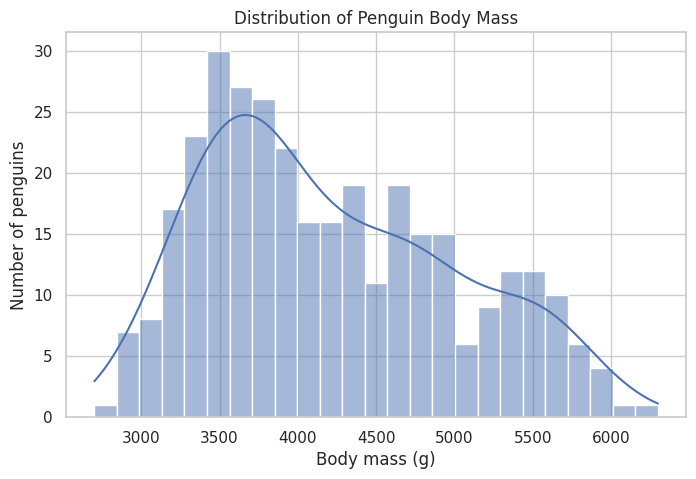

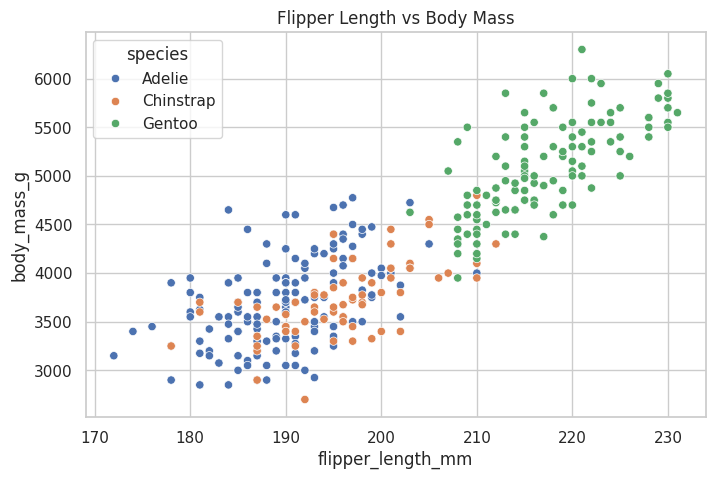

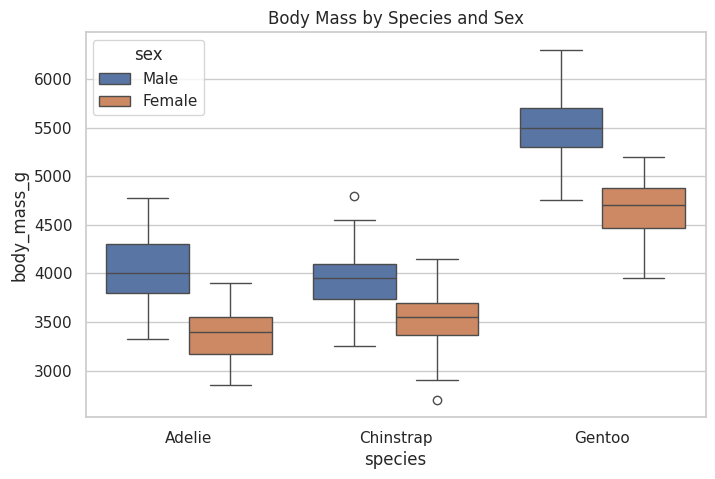

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.228626           0.653096   
bill_depth_mm           -0.228626       1.000000          -0.577792   
flipper_length_mm        0.653096      -0.577792           1.000000   
body_mass_g              0.589451      -0.472016           0.872979   
body_mass_kg             0.589451      -0.472016           0.872979   
bill_ratio               0.779230      -0.781246           0.801980   

                   body_mass_g  body_mass_kg  bill_ratio  
bill_length_mm        0.589451      0.589451    0.779230  
bill_depth_mm        -0.472016     -0.472016   -0.781246  
flipper_length_mm     0.872979      0.872979    0.801980  
body_mass_g           1.000000      1.000000    0.702179  
body_mass_kg          1.000000      1.000000    0.702179  
bill_ratio            0.702179      0.702179    1.000000  


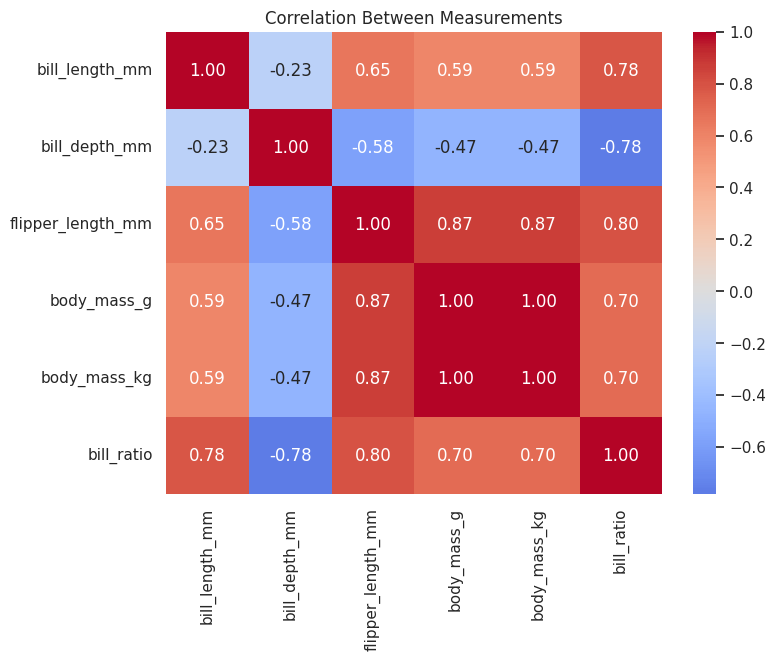

In [ ]:
# ============================================================
# CELL 5 — Selecting columns and filtering rows
# ============================================================

# Select ONE column (this gives a Series — a single column of values)
bill_lengths = df["bill_length_mm"]
print("Average bill length:", bill_lengths.mean())

# Select MULTIPLE columns — note the double brackets [[ ]]
subset = df[["species", "body_mass_g", "sex"]]
print("\nSubset preview:")
print(subset.head(3))

# FILTER rows with a condition. The condition inside [] produces
# True/False for each row, and pandas keeps only the True ones.
heavy = df[df["body_mass_g"] > 5000]
print("\nPenguins over 5000g:", len(heavy))

# Combine conditions with & (and) / | (or).
# Each condition MUST be wrapped in its own parentheses.
big_males = df[(df["body_mass_g"] > 5000) & (df["sex"] == "Male")]
print("Males over 5000g:", len(big_males))


# ============================================================
# CELL 6 — Counting and grouping (the most useful skill here)
# ============================================================

# .value_counts() counts how often each value appears in a column.
print("--- Penguins per species ---")
print(df["species"].value_counts())

# GROUPBY is the workhorse of data analysis. Read it as:
# "split the data by species, then compute the mean of each numeric column."
print("\n--- Average measurements by species ---")
print(df.groupby("species")[["bill_length_mm", "body_mass_g"]].mean())

# You can group by more than one column at a time.
print("\n--- Average body mass by species AND sex ---")
print(df.groupby(["species", "sex"])["body_mass_g"].mean())

# .agg() lets you ask for several statistics at once.
print("\n--- Multiple stats at once ---")
print(df.groupby("species")["body_mass_g"].agg(["count", "mean", "min", "max"]))


# ============================================================
# CELL 7 — Creating new columns and sorting
# ============================================================

# Math on a column applies to every row at once (no loop needed).
# Here: convert grams to kilograms.
df["body_mass_kg"] = df["body_mass_g"] / 1000

# A ratio can be more informative than either raw measurement.
df["bill_ratio"] = df["bill_length_mm"] / df["bill_depth_mm"]

# pd.cut() bins a numeric column into labeled categories.
df["size_class"] = pd.cut(
    df["body_mass_g"],
    bins=[0, 3500, 4500, 10000],       # the cutoff edges
    labels=["small", "medium", "large"]  # one label per bin
)

# .sort_values() reorders rows. ascending=False puts the biggest first.
print("--- 5 heaviest penguins ---")
print(df.sort_values("body_mass_g", ascending=False).head(5))

print("\n--- Count by size class ---")
print(df["size_class"].value_counts())


# ============================================================
# CELL 8 — Plot 1: distribution of a single variable
# ============================================================

# A histogram answers: "what values are common, and what's the spread?"
plt.figure(figsize=(8, 5))          # set the canvas size in inches
sns.histplot(data=df, x="body_mass_g", bins=25, kde=True)
#   bins=25  -> how many bars to split the range into
#   kde=True -> overlay a smooth curve of the distribution
plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body mass (g)")
plt.ylabel("Number of penguins")
plt.show()                          # renders the plot in Colab


# ============================================================
# CELL 9 — Plot 2: relationship between two variables
# ============================================================

# A scatter plot answers: "do these two things move together?"
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",   # color the dots by species — this is where patterns pop out
)
plt.title("Flipper Length vs Body Mass")
plt.show()


# ============================================================
# CELL 10 — Plot 3: comparing groups
# ============================================================

# A box plot summarizes each group: the box covers the middle 50% of values,
# the line inside is the median, and dots beyond the whiskers are outliers.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="species", y="body_mass_g", hue="sex")
plt.title("Body Mass by Species and Sex")
plt.show()


# ============================================================
# CELL 11 — Correlation: which numbers move together?
# ============================================================

# Correlation ranges from -1 to +1.
#  +1 = as one goes up, the other goes up perfectly
#   0 = no linear relationship
#  -1 = as one goes up, the other goes down
# numeric_only=True tells pandas to skip the text columns.
corr = df.corr(numeric_only=True)
print(corr)

# A heatmap makes the correlation table much easier to read.
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
#   annot=True -> print the number inside each square
#   center=0   -> white at zero, so red/blue means positive/negative
plt.title("Correlation Between Measurements")
plt.show()

Rows kept: 214 out of 333
species
Adelie       146
Chinstrap     68
Name: count, dtype: int64 

--- Correlation: Adelie + Chinstrap ---
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm               1.00           0.27               0.50   
bill_depth_mm                0.27           1.00               0.38   
flipper_length_mm            0.50           0.38               1.00   
body_mass_g                  0.30           0.59               0.49   

                   body_mass_g  
bill_length_mm            0.30  
bill_depth_mm             0.59  
flipper_length_mm         0.49  
body_mass_g               1.00  


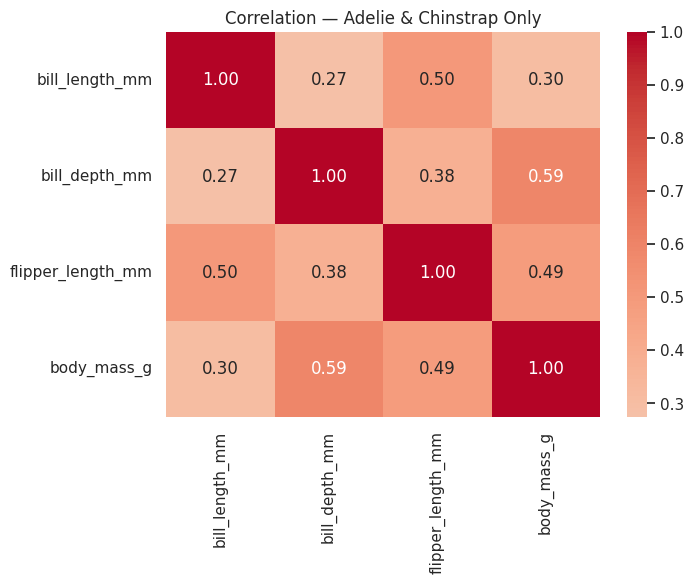


--- flipper_length_mm vs body_mass_g ---
All three species: 0.873
Adelie + Chinstrap: 0.488
Adelie alone: 0.465
Chinstrap alone: 0.642
Gentoo alone: 0.711


In [ ]:
# ============================================================
# CELL 11b — Correlation for Adelie and Chinstrap only
# ============================================================

# .isin() checks each row against a LIST of values and returns True/False.
# This is cleaner than writing (df["species"] == "Adelie") | (df["species"] == "Chinstrap")
two_species = df[df["species"].isin(["Adelie", "Chinstrap"])]

print("Rows kept:", len(two_species), "out of", len(df))
print(two_species["species"].value_counts(), "\n")

# Pick just the raw measurement columns. If you skip this, the correlation
# table also includes the extra columns we made in Cell 7 (body_mass_kg,
# bill_ratio), which are derived from these and will show fake-perfect
# correlations of 1.00.
measurements = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

corr_two = two_species[measurements].corr()
print("--- Correlation: Adelie + Chinstrap ---")
print(corr_two.round(2))

# Heatmap of the same table
plt.figure(figsize=(7, 5))
sns.heatmap(corr_two, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation — Adelie & Chinstrap Only")
plt.show()


# ============================================================
# Compare it against the full dataset and against each species alone
# ============================================================

# Correlation of flipper length vs body mass, computed on different slices.
# .corr() on a single column takes the other column as its argument.
print("\n--- flipper_length_mm vs body_mass_g ---")
print("All three species:", round(df["flipper_length_mm"].corr(df["body_mass_g"]), 3))
print("Adelie + Chinstrap:", round(two_species["flipper_length_mm"].corr(two_species["body_mass_g"]), 3))

# Loop through each species and compute it separately.
for name, group in df.groupby("species"):
    r = group["flipper_length_mm"].corr(group["body_mass_g"])
    print(f"{name} alone: {round(r, 3)}")